<a href="https://colab.research.google.com/github/juliafoliveira-tech/Bioestat-stica/blob/main/Semin%C3%A1rio.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

* Julia Feitosa NºUSP: 16228410
* Raissa Pereira Lima da Silva NºUSP: 14605077
* Stéfani Machado NºUSP: 15291452

In [26]:
import pandas as pd

df = pd.read_excel('Seminario.xlsx', header=1)

In [31]:
print(df.columns.tolist())
display(df.head())

['Unnamed: 0', 'Grupo taxonômico', 'Táxons avaliados', 'Táxons ameaçados']


,Unnamed: 0,Grupo taxonômico,Táxons avaliados,Táxons ameaçados
0,Vertebrados,Mammalia,732.000,"111 (15,1%)"
1,NaN,Aves,1.979,"236 (11,9%)"
2,NaN,Reptilia,732.000,"85 (11,6%)"
3,NaN,Amphibia,973.000,"41 (4,2%)"
4,NaN,Actinopterygii (Marinhos),1.201,"43 (3,6%)"


O gráfico abaixo apresenta os táxons avaliados e ameaçados entre os grupos de invertebrados e vertebrados.

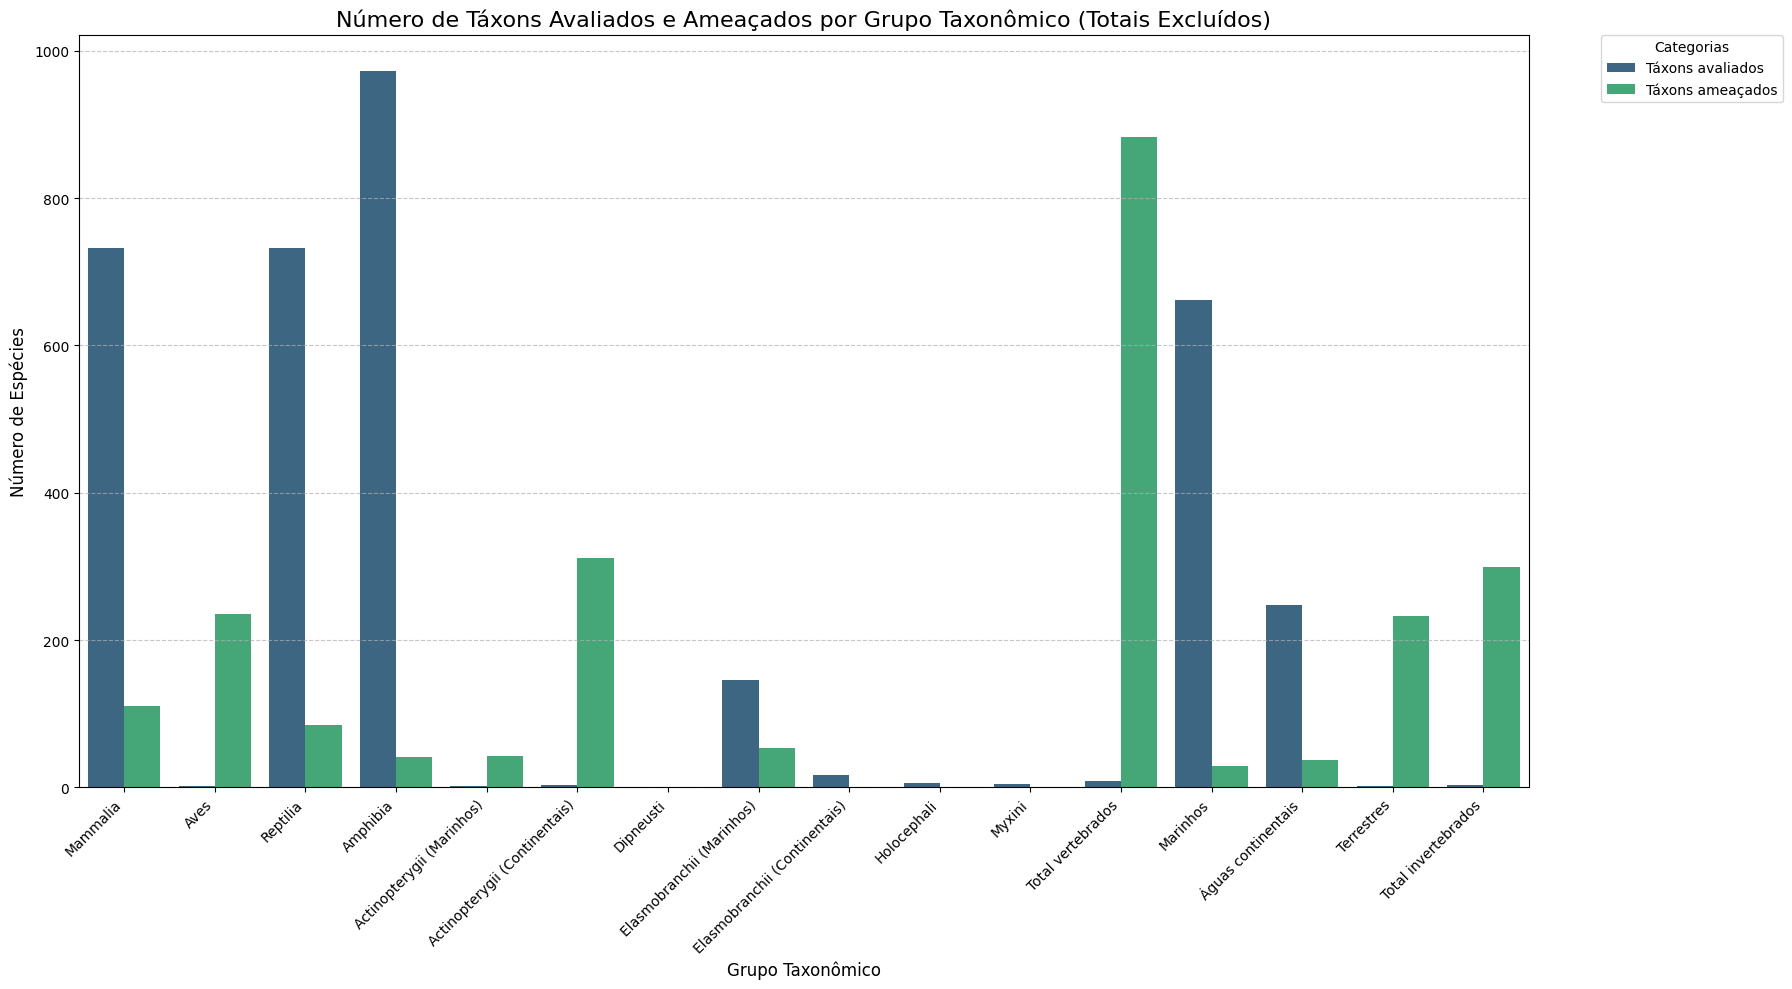

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# As colunas foram identificadas como ['Unnamed: 0', 'Grupo taxonômico', 'Táxons avaliados', 'Táxons ameaçados']
# O 'Unnamed: 0' parece ser uma categoria superior ou índice que não é útil para o gráfico
# Vamos focar em 'Grupo taxonômico', 'Táxons avaliados' e 'Táxons ameaçados'

# Criar uma cópia do DataFrame para evitar SettingWithCopyWarning
df_taxons_processed = df[['Grupo taxonômico', 'Táxons avaliados', 'Táxons ameaçados']].copy()

# Limpar a coluna 'Táxons ameaçados': extrair apenas o número antes do parênteses
df_taxons_processed['Táxons ameaçados'] = df_taxons_processed['Táxons ameaçados'].astype(str).str.extract('(\\d+)', expand=False)

# Converter colunas numéricas para o tipo numérico, preenchendo NaN com 0
numerical_cols = ['Táxons avaliados', 'Táxons ameaçados']
for col in numerical_cols:
    # Substituir ',' por '.' para garantir a conversão correta para números, se necessário
    df_taxons_processed[col] = df_taxons_processed[col].astype(str).str.replace(',', '.', regex=False)
    df_taxons_processed[col] = pd.to_numeric(df_taxons_processed[col], errors='coerce').fillna(0)

# Remover linhas onde 'Grupo taxonômico' é NaN
df_taxons_processed.dropna(subset=['Grupo taxonômico'], inplace=True)

# Filtrar as linhas de totais solicitadas pelo usuário, incluindo 'Vertebrados' e 'Invertebrados'
excluded_groups = [
    'Total de Espécies',
    'Total de vertebrados',
    'Total de invertebrados',
    'TOTAL',
    'Vertebrados',
    'Invertebrados'
]

df_taxons_filtered = df_taxons_processed[~df_taxons_processed['Grupo taxonômico'].isin(excluded_groups)].copy()

# Derreter o DataFrame filtrado para o formato longo
df_melted_taxons = df_taxons_filtered.melt(
    id_vars=['Grupo taxonômico'],
    value_vars=['Táxons avaliados', 'Táxons ameaçados'],
    var_name='Categoria',
    value_name='Número de Espécies'
)

# Criar o gráfico de barras usando Seaborn
plt.figure(figsize=(18, 10))
sns.barplot(
    data=df_melted_taxons,
    x='Grupo taxonômico',
    y='Número de Espécies',
    hue='Categoria',
    palette='viridis'
)

plt.title('Número de Táxons Avaliados e Ameaçados por Grupo Taxonômico (Totais Excluídos)', fontsize=16)
plt.xlabel('Grupo Taxonômico', fontsize=12)
plt.ylabel('Número de Espécies', fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(fontsize=10)
plt.legend(title='Categorias', bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()